In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

from pathlib import Path
import re

In [2]:
def excel_to_csv(file_path, skip_rows, name=None):
    df = pd.read_excel(file_path, skiprows=skip_rows)
    df.to_csv(name + '.csv', index=False)
    
def hours_to_sec(file_path, time_hour_col = 't_h', time_sec_col = 't_s'):
    df = pd.read_csv(file_path)
    
    df[time_hour_col] = df[time_hour_col] * 3600
    df.insert(0, time_sec_col, value=df[time_hour_col])
    df = df.drop(columns=[time_hour_col])
    df[time_sec_col] = df[time_sec_col].round().astype(int)
    
    file_name = file_path.rsplit('\\')[1]
    df.to_csv('new_' + file_name, index=False)

def mV_to_V(file_path, column_name):
    df = pd.read_csv(file_path)
    
    for i in column_name:
        df[i] = (-df[i])/1000
    
    file_name = file_path.rsplit('\\')[-1]
    df.to_csv('new_' + file_name, index=False)

#### folder_path : str | Path => Folder containing the data files <br> file_pattern : str, default="*.csv" => Pattern of files to read (e.g. "*.csv", "*.xlsx") <br> file_reader : callable, default=pd.read_csv => Function used to read each file <br> sensor_pattern : str, default=r"R\d+" Regex pattern describing valid sensor names <br> separator : str, default="_" Character used to split filenames.

In [6]:
def organize_sensor_data(folder_path: str | Path) -> dict[str, pd.DataFrame]:
    
    folder = Path(folder_path) # Path => creates Path obj. representing folder's location & r => raw string

    all_files = {} 
    for file in folder.glob("*.csv"): # glob() searches for files matching a pattern(here *.csv, where * => anything).
        all_files[file.stem] = pd.read_csv(file) # file.stem => removes file's extension i.e reads 'file.csv' as 'file'
        
    sensor_names = set()
    for df in all_files.values():
        sensor_names.update(col for col in df.columns if re.fullmatch(r"R\d+", str(col)))
    # contains name of all uniques sensors present in every file
    # or we can also do this "sensor_names = {col for col in sensor_names if col.startswith("R") and col[1:].isdigit()}"
    
    sensor_data = {}
    for sensor in sorted(sensor_names):
        temp = pd.DataFrame()

        for file_name, df in all_files.items():
            if sensor not in df.columns:
                continue

            col_name = file_name.split('_')[1]
            temp[f"{df.columns[0]}_{col_name}"] = df.iloc[:, 0]
            temp['E_' + col_name] = df[sensor]
        sensor_data[sensor] = temp
        
    return sensor_data

In [11]:
sensor_data = organize_sensor_data(folder_path=r"../clean_name_dataset")

In [12]:
sensor_data['R75']

,t_s_02-10-2026,E_02-10-2026,t_s_12-08-2025,E_12-08-2025,t_s_06-17-2026,E_06-17-2026,t_s_12-16-2025,E_12-16-2025,t_s_04-21-2026,E_04-21-2026
0,0,0.004364,0,0.005171,0.0,-0.018577,0,0.035651,0.0,0.013109
1,5,0.004410,5,0.005807,10.0,-0.016816,5,0.035988,10.0,0.014754
2,10,0.004492,10,0.006368,20.0,-0.015629,10,0.036215,20.0,0.015821
3,15,0.004492,15,0.006872,30.0,-0.014785,15,0.036418,30.0,0.016602
4,20,0.004492,20,0.007313,40.0,-0.014129,20,0.036590,40.0,0.017071
...,...,...,...,...,...,...,...,...,...,...
2542,12710,-0.154727,12710,-0.194591,NaN,NaN,12710,-0.137227,NaN,NaN
2543,12715,-0.154727,12715,-0.194606,NaN,NaN,12715,-0.137227,NaN,NaN
2544,12720,-0.154727,12720,-0.194630,NaN,NaN,12720,-0.137227,NaN,NaN
2545,12725,-0.154727,12725,-0.194645,NaN,NaN,12725,-0.137305,NaN,NaN


In [13]:
def plot_time_series_sensor(sensor_data, nrows=None, ncols=None, figsize=(10, 10), title="Time Series Plot", label_fontsize=7, title_fontsize=18):    
    
    n = len(sensor_data.keys())
    if nrows is None or ncols is None:
        ncols = int(np.ceil(np.sqrt(n)))
        nrows = int(np.ceil(n / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()
    
    for i, sensor in enumerate(sensor_data.keys()): # i=> 0 to 46, sensor => R75,...
        df = sensor_data[sensor] # sensor_data[sensor] => df with t_dat and E_date
        
        for j in range(0, df.shape[1], 2): # df.shape[1] => total number of columns
            label = df.columns[j+1].split('_')[1]
            axes[i].plot(df.iloc[:,j], df.iloc[:,j+1]*(-1000), label=label) # V -> mV
        axes[i].set_title(sensor)
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Potential (mV)")
        axes[i].legend(fontsize=label_fontsize, loc='upper left')
        #axes[i].set_ylim(df[col].min()-5, df[col].max()+5)
        axes[i].grid(True, linestyle="--", alpha=0.6)
    
    for j in range(n, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(title, fontsize=title_fontsize, y = 1.001)
    plt.tight_layout()
    plt.show()

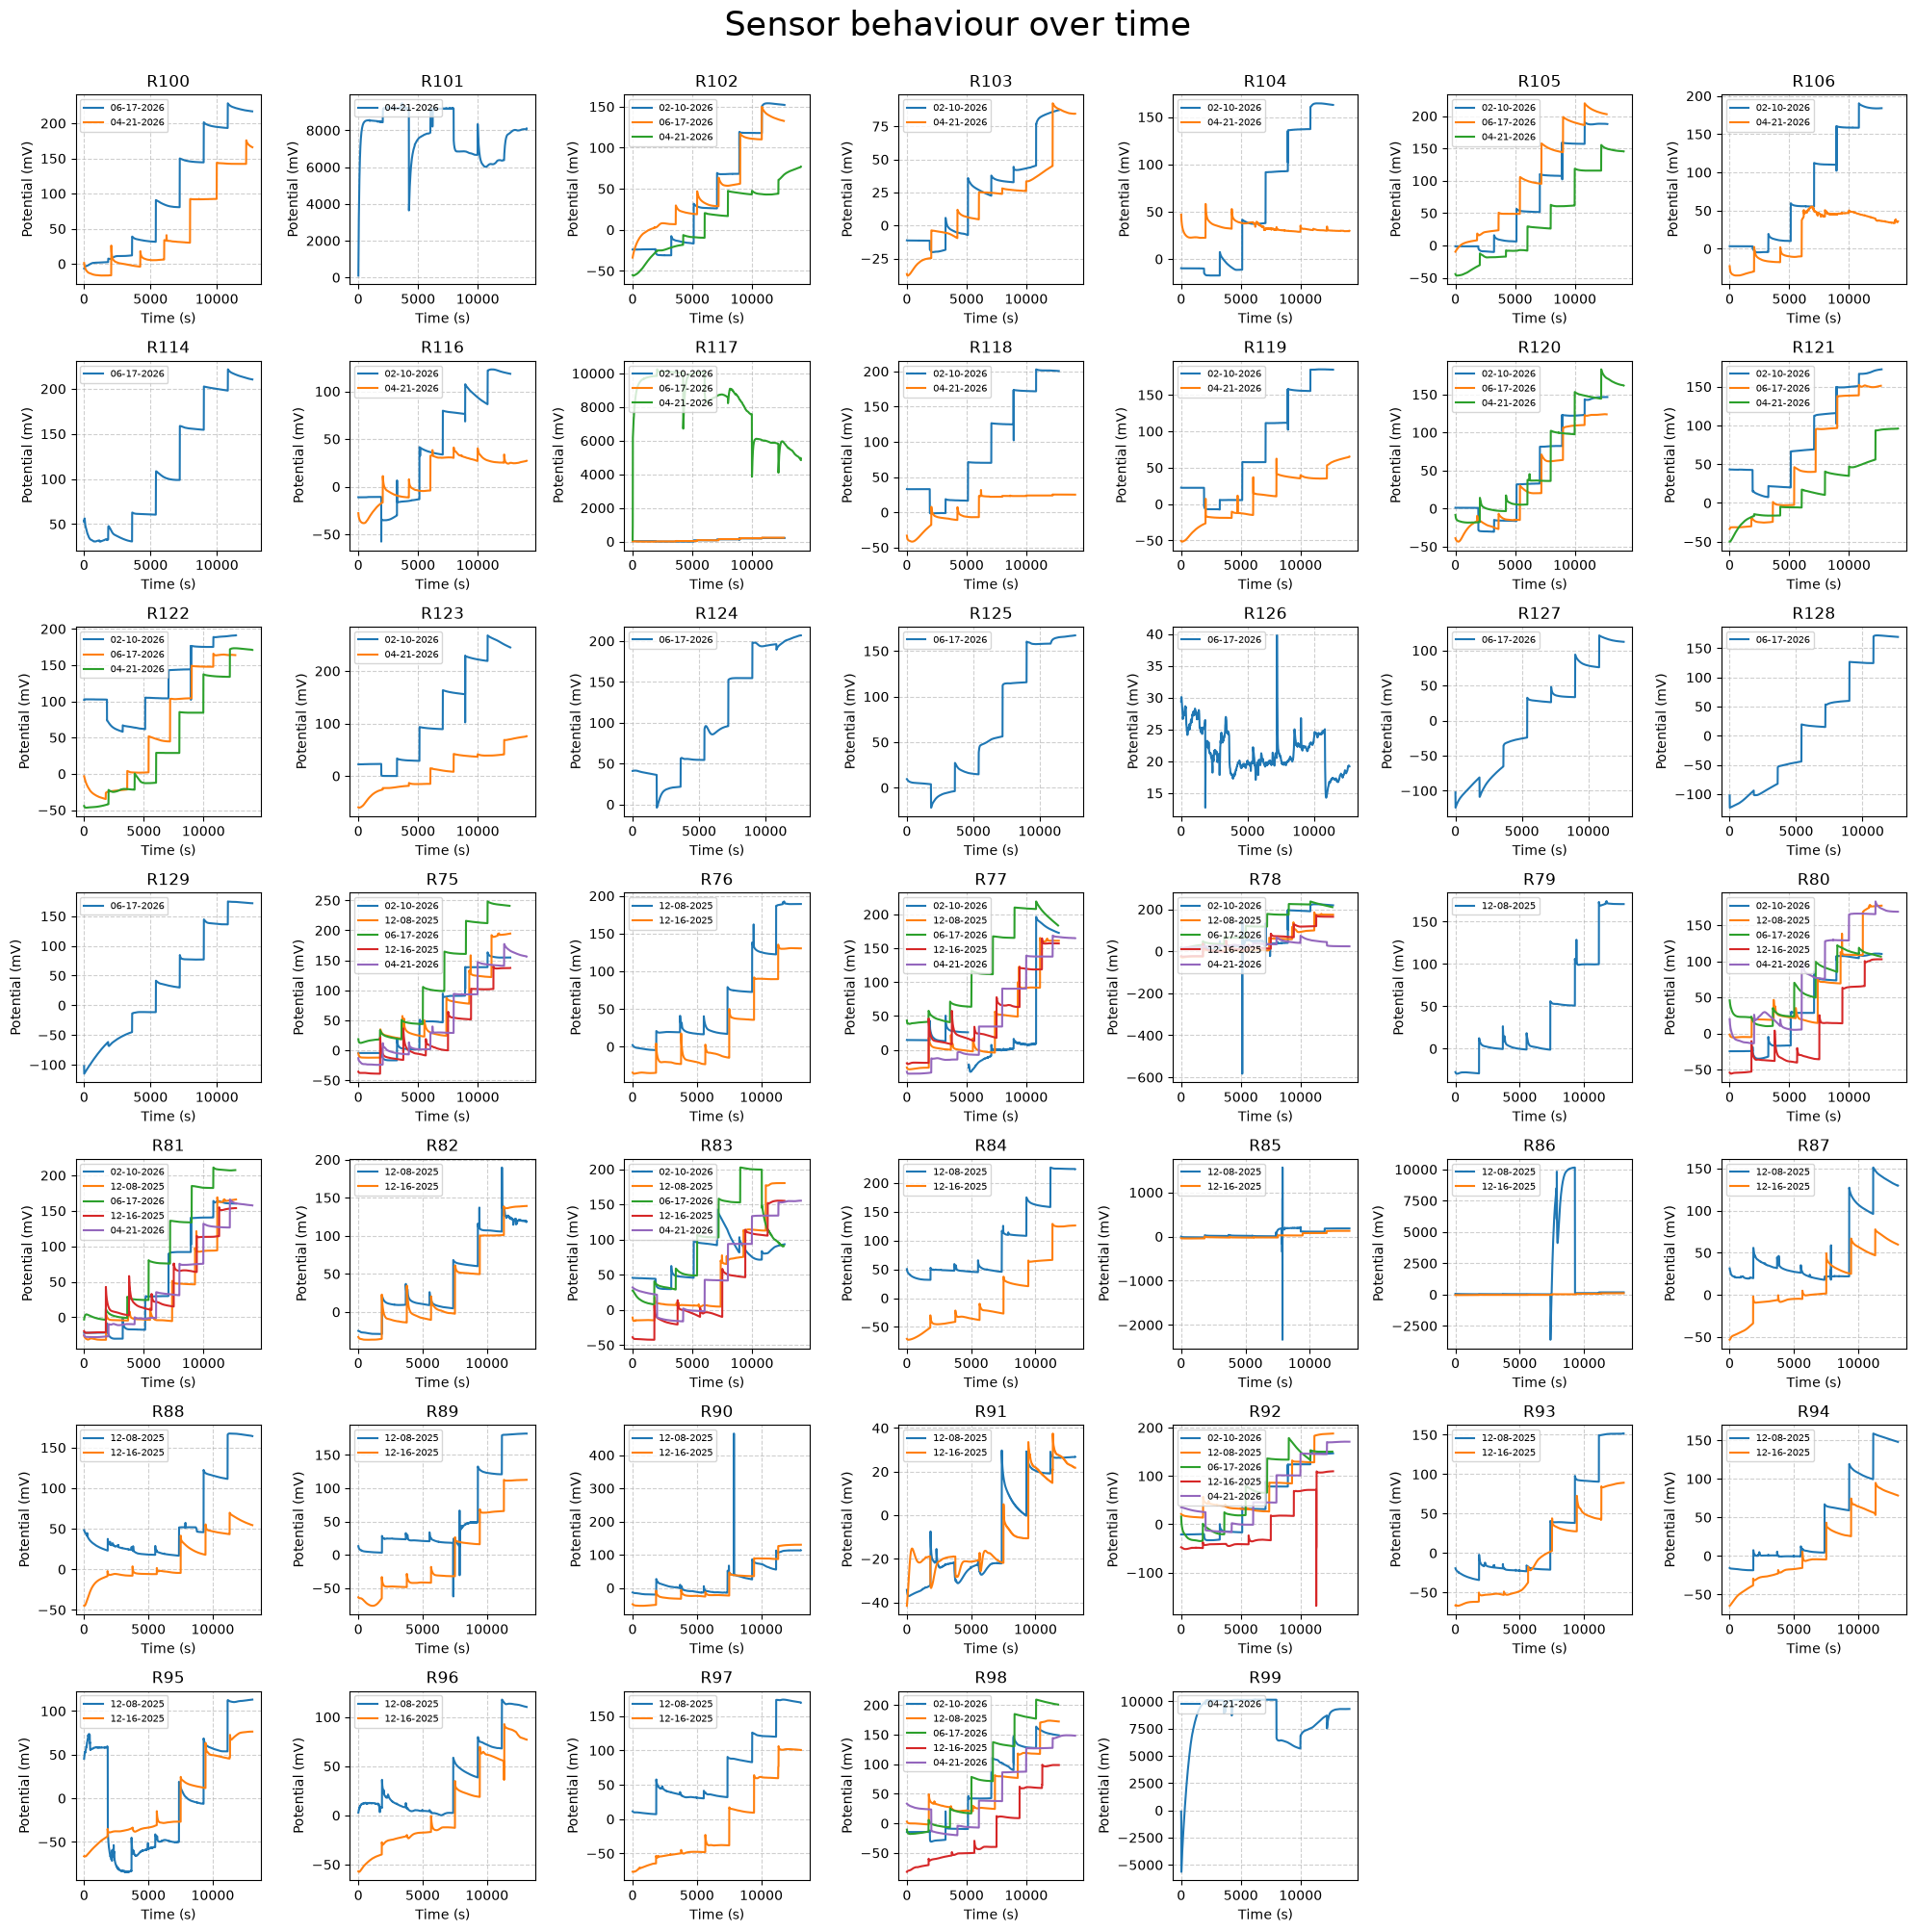

In [14]:
plot_time_series_sensor(sensor_data, figsize=(20,20), title='Sensor behaviour over time', title_fontsize=25)

In [15]:
def calculate_potential(sensor_data, experiment_info, method='last'): # function to get calibration curve data
    calibration_data = {}
    
    for el, df in sensor_data.items():
        dfs = []
        
        for i in range(0, df.shape[1], 2):
            t = df.iloc[:, i].values
            E = df.iloc[:, i + 1].values
            date = df.columns[i + 1].replace("E_", "")
            logC = []
            potential = []
            
            for start, end, conc in experiment_info[date]:
                mask = (t >= start * 3600) & (t < end * 3600)
                filtered = E[mask]
                logC.append(np.log10(conc))
                if method == "average":
                    potential.append(filtered.mean() if filtered.size else np.nan)
                elif method == "last":
                    potential.append(filtered[-1] if filtered.size else np.nan)
                else:
                    raise ValueError("method must be 'average' or 'last'")
            
            if method == "average":
                temp = pd.DataFrame({f"logC_{date}": logC, f"Avg_OCP_{date}": potential})
            else:
                temp = pd.DataFrame({f"logC_{date}": logC, f"Last_OCP_{date}": potential})
            dfs.append(temp)
            
        calibration_data[el] = pd.concat(dfs, axis=1)
    return calibration_data

In [16]:
experiment_info = {
    "12-08-2025": [(0, 0.51111111, 1e-8), (0.51111111, 1.025, 1e-7), (1.025, 1.5375, 1e-6), (1.5375, 2.05, 1e-5), (2.05, 2.58194444, 1e-4),
                  (2.58194444, 3.1, 1e-3), (3.1, np.inf, 1e-2)],
    "12-16-2025": [(0, 0.5069444444444444, 1e-8), (0.5069444444444444, 1.0472222222222223, 1e-7), (1.0472222222222223, 1.5708333333333333, 1e-6),
                  (1.5708333333333333, 2.0875, 1e-5), (2.0875, 2.623611111111111, 1e-4), (2.623611111111111, 3.1444444444444444, 1e-3),
                  (3.1444444444444444, np.inf, 1e-2)],
    "02-10-2026": [(0, 0.9, 1e-6), (0.9, 1.42222222222222, 1e-5), (1.42222222222222, 1.96527777777778, 1e-4), (1.96527777777778, 2.48472222222222, 1e-3),
                  (2.48472222222222, 3.00833333333333, 1e-2), (3.00833333333333, np.inf, 1e-1)],
    "04-21-2026": [(0, 0.5694444444444444, 1e-8),(0.5694444444444444, 1.1777777777777778, 1e-7),(1.1777777777777778, 1.6777777777777778, 1e-6),
                  (1.6777777777777778, 2.2194444444444446, 1e-5),(2.2194444444444446, 2.7777777777777777, 1e-4),(2.7777777777777777,3.3944444444444444,1e-3),
                  (3.3944444444444444, np.inf, 1e-2)],
    "06-17-2026": [(0, 0.5055555555555555, 1e-7), (0.5055555555555555, 1.0055555555555555, 1e-6),(1.0055555555555555, 1.5027777777777778, 1e-5),
                  (1.5027777777777778, 2.0027777777777778, 1e-4), (2.0027777777777778, 2.5055555555555555, 1e-3), 
                  (2.5055555555555555, 3.0083333333333333,1e-2), (3.0083333333333333, np.inf, 1e-1)]
}

In [17]:
calibration_data = calculate_potential(sensor_data, experiment_info, method='last')
calibration_data['R75']

,logC_02-10-2026,Last_OCP_02-10-2026,logC_12-08-2025,Last_OCP_12-08-2025,logC_06-17-2026,Last_OCP_06-17-2026,logC_12-16-2025,Last_OCP_12-16-2025,logC_04-21-2026,Last_OCP_04-21-2026
0,-6.0,0.016680,-8.0,0.012125,-7.0,-0.018215,-8.0,0.039012,-8.0,0.023711
1,-5.0,-0.001289,-7.0,-0.019645,-6.0,-0.018254,-7.0,0.016024,-7.0,0.006836
2,-4.0,-0.094648,-6.0,-0.022906,-5.0,-0.043778,-6.0,0.008500,-6.0,-0.001914
3,-3.0,-0.091133,-5.0,-0.024254,-4.0,-0.098676,-5.0,0.000054,-5.0,-0.029023
4,-2.0,-0.138634,-4.0,-0.077696,-3.0,-0.160708,-4.0,-0.051601,-4.0,-0.093477
5,-1.0,-0.154727,-3.0,-0.122098,-2.0,-0.212020,-3.0,-0.102227,-3.0,-0.140742
6,NaN,NaN,-2.0,-0.194669,-1.0,-0.240911,-2.0,-0.137305,-2.0,-0.156367


In [20]:
def _best_region(x, y, min_points=4, r2_threshold=0.98, prefer="r2"):
    """x, y already NaN-free and sorted by x. Returns (xs, ys, slope, int, r2) or None."""
    n = len(x)
    best, best_key = None, None
    for s in range(n):
        for e in range(s + min_points, n + 1):
            xs, ys = x[s:e], y[s:e]
            # if xs.max() - xs.min() == 0:
            #     continue
            slope, intercept, r, _, _ = linregress(xs, ys)
            r2 = r * r
            if r2 < r2_threshold:
                continue
            key = (e - s, r2) if prefer == "width" else (r2, e - s)
            if best_key is None or key > best_key:
                best_key, best = key, (xs, ys, slope, intercept, r2)
    return best

In [21]:
def plot_sensor_calibration(ax, df, sensor, min_points=4, r2_threshold=0.98, prefer="r2", cmap_name="tab10", show_slope=True):
    """Overlay every date in one sensor's (logC_<date>, OCP_<date>) frame on `ax`."""
    cmap = plt.get_cmap(cmap_name)
    pairs = [(df.columns[i], df.columns[i + 1]) for i in range(0, df.shape[1], 2)] # pairs of logC & Avg/Last_OCP datewise
    plotted = 0
    
    for k, (xcol, ycol) in enumerate(pairs):
        date = xcol.replace("logC_", "", 1)   # date
        sub = df[[xcol, ycol]].dropna()       # per-date padding NaNs out
        x = sub[xcol].to_numpy(float)         # logC
        y = sub[ycol].to_numpy(float)*(-1000) # Avg/Last_OCP
        order = np.argsort(x)
        x, y = x[order], y[order]
        color = cmap(k % 10)

        ax.plot(x, y, marker="o", mfc="none", mec=color, ls=":", lw=0.8, ms=4) # all points for this date: hollow markers, faint dotted link

        best = _best_region(x, y, min_points, r2_threshold, prefer) # x_best, y_best, slope, intercept, r2        
        if best is None:
            ax.plot([], [], marker="o", color=color, ls="none", label=f"{date} (no region)")
            continue
        xs, ys, slope, intercept, r2 = best
        ax.plot(xs, ys, marker="o", color=color, ls="none", ms=6)   # region points
        
        xfit = xs
        lbl = f"{date}: {slope:.1f} mV/dec, R²={r2:.3f}" if show_slope else date
        ax.plot(xfit, intercept + slope * xfit, ls="--", color=color, lw=1.8, label=lbl)
        plotted += 1

    ax.set_title(sensor)
    ax.set_xlabel("logC")
    ax.set_ylabel("OCP (mV)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper left")
    return plotted

In [22]:
def plot_all_sensors(cal_dict, sensors=None, ncols=4, figsize=(5, 5), per_figure=False, **kw):
    """
    Grid of sensors (default) — each subplot overlays that sensor's dates.
    per_figure=True -> one separate, larger figure per sensor instead.
    """
    sensors = sensors if sensors is not None else list(cal_dict.keys())

    if per_figure:
        for s in sensors:
            fig, ax = plt.subplots(figsize=panel)
            plot_sensor_calibration(ax, cal_dict[s], s, **kw)
            fig.tight_layout()
        plt.show()
        return

    nrows = int(np.ceil(len(sensors) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0] * ncols, figsize[1] * nrows))
    axes = np.atleast_1d(axes).flatten()
    for i, s in enumerate(sensors):
        plot_sensor_calibration(axes[i], cal_dict[s], s, **kw)
    for j in range(len(sensors), len(axes)):
        axes[j].axis("off")
    fig.tight_layout()
    return fig

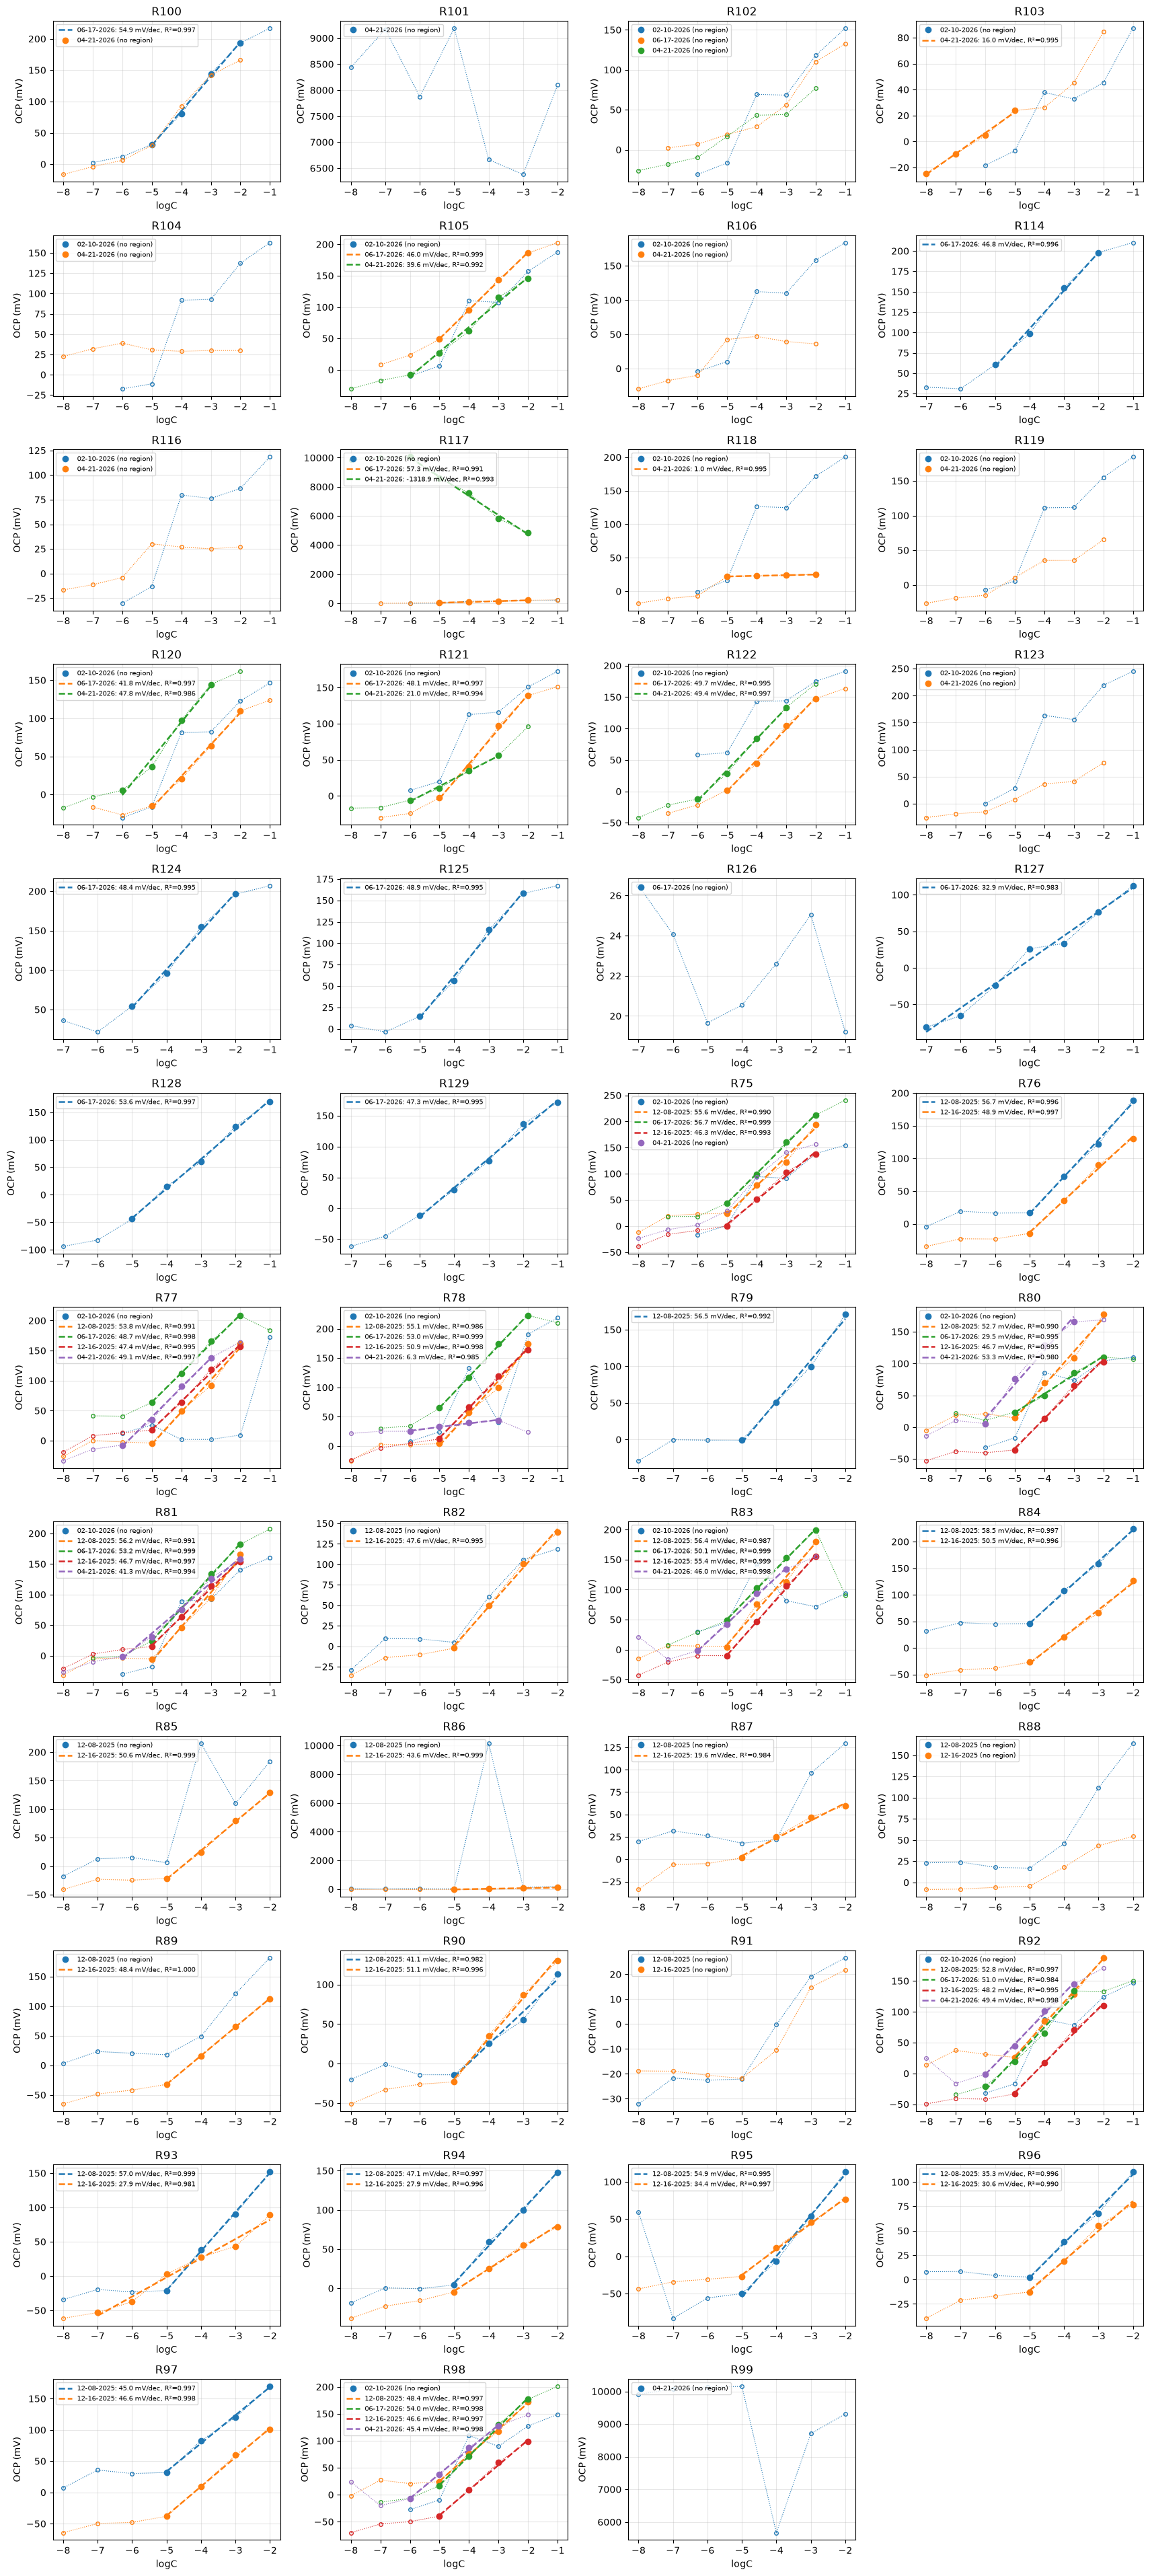

In [23]:
fig = plot_all_sensors(calibration_data, ncols=4, min_points=4, r2_threshold=0.98, figsize=(4.3,3.2))
plt.show()

### Working with sensors having atleast 4 sets of readings

In [24]:
keep = []
for i in list(sensor_data.keys()):
    if sensor_data[i].shape[1] < 8:
        del sensor_data[i]
print(sensor_data.keys())

keep = []
for i in list(calibration_data.keys()):
    if calibration_data[i].shape[1] < 8:
        del calibration_data[i]
print(calibration_data.keys())

dict_keys(['R75', 'R77', 'R78', 'R80', 'R81', 'R83', 'R92', 'R98'])
dict_keys(['R75', 'R77', 'R78', 'R80', 'R81', 'R83', 'R92', 'R98'])


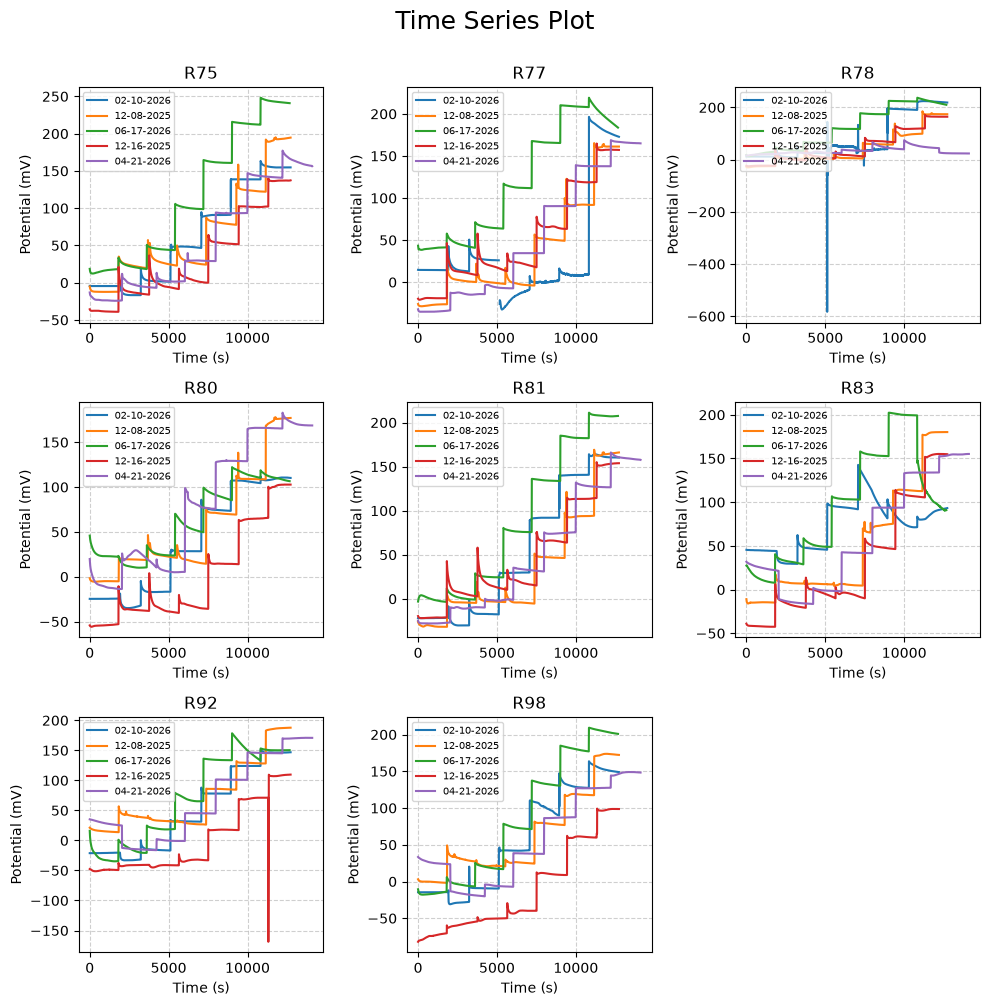

In [25]:
plot_time_series_sensor(sensor_data)

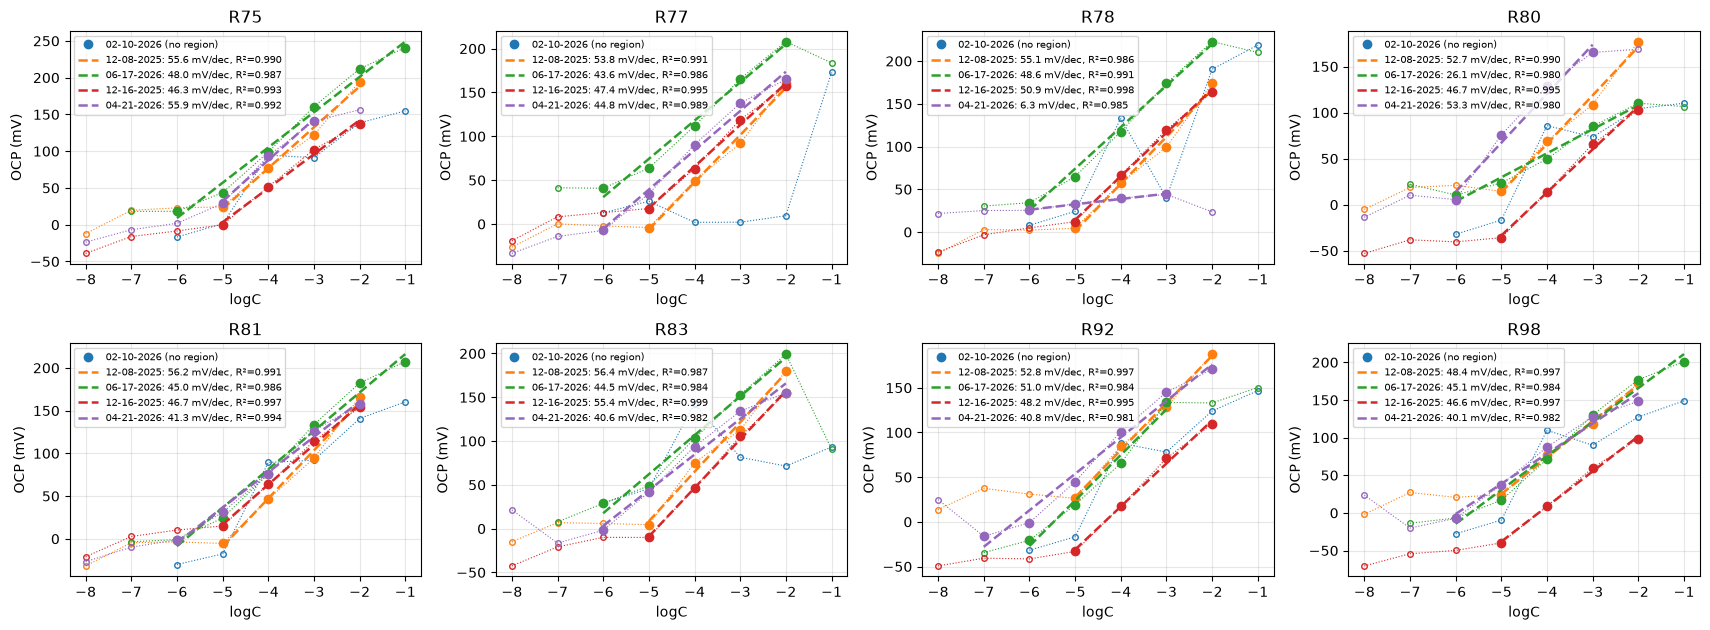

In [26]:
fig = plot_all_sensors(calibration_data, ncols=4, min_points=3, r2_threshold=0.98, figsize=(4.3,3.2), prefer='width')
plt.show()

In [27]:
df = calibration_data['R75']

In [28]:
df

,logC_02-10-2026,Last_OCP_02-10-2026,logC_12-08-2025,Last_OCP_12-08-2025,logC_06-17-2026,Last_OCP_06-17-2026,logC_12-16-2025,Last_OCP_12-16-2025,logC_04-21-2026,Last_OCP_04-21-2026
0,-6.0,0.016680,-8.0,0.012125,-7.0,-0.018215,-8.0,0.039012,-8.0,0.023711
1,-5.0,-0.001289,-7.0,-0.019645,-6.0,-0.018254,-7.0,0.016024,-7.0,0.006836
2,-4.0,-0.094648,-6.0,-0.022906,-5.0,-0.043778,-6.0,0.008500,-6.0,-0.001914
3,-3.0,-0.091133,-5.0,-0.024254,-4.0,-0.098676,-5.0,0.000054,-5.0,-0.029023
4,-2.0,-0.138634,-4.0,-0.077696,-3.0,-0.160708,-4.0,-0.051601,-4.0,-0.093477
5,-1.0,-0.154727,-3.0,-0.122098,-2.0,-0.212020,-3.0,-0.102227,-3.0,-0.140742
6,NaN,NaN,-2.0,-0.194669,-1.0,-0.240911,-2.0,-0.137305,-2.0,-0.156367


In [29]:
df.shape

(7, 10)

In [30]:
for i in range(0,df.shape[1],2): # i = 0,2,4,6,8
    print(np.array(df.iloc[:,i+1][(df.iloc[:,i] == -4.0)]))

[-0.09464836]
[-0.07769585]
[-0.09867611]
[-0.05160141]
[-0.09347725]


In [31]:
for i in list(calibration_data.keys()):
    df = calibration_data[i]
    print(df)

   logC_02-10-2026  Last_OCP_02-10-2026  logC_12-08-2025  Last_OCP_12-08-2025  \
0             -6.0             0.016680             -8.0             0.012125   
1             -5.0            -0.001289             -7.0            -0.019645   
2             -4.0            -0.094648             -6.0            -0.022906   
3             -3.0            -0.091133             -5.0            -0.024254   
4             -2.0            -0.138634             -4.0            -0.077696   
5             -1.0            -0.154727             -3.0            -0.122098   
6              NaN                  NaN             -2.0            -0.194669   

   logC_06-17-2026  Last_OCP_06-17-2026  logC_12-16-2025  Last_OCP_12-16-2025  \
0             -7.0            -0.018215             -8.0             0.039012   
1             -6.0            -0.018254             -7.0             0.016024   
2             -5.0            -0.043778             -6.0             0.008500   
3             -4.0         

In [32]:
vals = {}
for i in list(calibration_data.keys()):
    df = calibration_data[i]
    potential = []
    for col in range(0,df.shape[1],2): # i = 0,2,4,6,8
        ocp = (df.iloc[:, col + 1][df.iloc[:, col] == -4.0]*(-1000)).to_numpy()[0]
        potential.append(round(ocp,1))
    vals[i] = potential
vals.keys()

dict_keys(['R75', 'R77', 'R78', 'R80', 'R81', 'R83', 'R92', 'R98'])

In [33]:
for i in list(vals.keys()):
    print(f'{i} - {vals[i]}')

R75 - [np.float64(94.6), np.float64(77.7), np.float64(98.7), np.float64(51.6), np.float64(93.5)]
R77 - [np.float64(2.0), np.float64(49.2), np.float64(111.7), np.float64(63.3), np.float64(90.5)]
R78 - [np.float64(133.0), np.float64(57.6), np.float64(117.4), np.float64(66.7), np.float64(39.6)]
R80 - [np.float64(85.9), np.float64(69.3), np.float64(49.6), np.float64(14.0), np.float64(128.8)]
R81 - [np.float64(89.3), np.float64(46.4), np.float64(75.7), np.float64(63.8), np.float64(75.5)]
R83 - [np.float64(142.7), np.float64(75.3), np.float64(103.0), np.float64(46.4), np.float64(93.7)]
R92 - [np.float64(88.0), np.float64(84.5), np.float64(65.5), np.float64(17.2), np.float64(101.0)]
R98 - [np.float64(109.7), np.float64(76.8), np.float64(71.3), np.float64(8.9), np.float64(87.5)]


In [34]:
diff = {}
for i in list(vals.keys()):
    temp = []
    value_array = vals[i]
    #print(value_array)
    #differ = np.diff(value_array)
    # temp.append(value_array)
    # diff[i] = temp